_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>Frauke von der Haar, Urmi Jana </span>

LLM Disclaimer: <span style='background: yellow'> Urmi used Claude code to generate the plots for the spike waveforms for Task 3.  </span>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import PCA
from __future__ import annotations  # for Python 3.8 and below

# black is a code formatter (see https://github.com/psf/black).
# It will automatically format the code you write in the cells imposing consistent Python style.
%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

In [2]:
# matplotlib style file
# Template for style file: https://matplotlib.org/stable/tutorials/introductory/customizing.html#customizing-with-style-sheets
plt.style.use("../matplotlib_style.txt")

## Load data

In [3]:
fs = 30000.0  # sampling rate of the signal in Hz
dt = 1 / fs
cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
x = pd.read_csv("../data/nds_cl_1.csv", header=0, names=cols)

In [4]:
x.head()

,Ch1,Ch2,Ch3,Ch4
0,-141,-184,-316,-191
1,-136,-167,-290,-196
2,-168,-185,-306,-219
3,-147,-188,-332,-219
4,-165,-196,-331,-206


In [5]:
x.values

array([[-141, -184, -316, -191],
       [-136, -167, -290, -196],
       [-168, -185, -306, -219],
       ...,
       [1006, 1058, 1239, 1118],
       [ 977, 1092, 1235, 1125],
       [ 967, 1091, 1255, 1141]], shape=(19199999, 4))

## Task 1: Filter Signal

In order to detect action potentials, the first step is to filter out low frequency fluctuations (LFP) and high frequency noise. Determine appropriate filter settings and implement the filtering in the function ```filter_signal()```. A typical choice for this task would be a <mark>butterworth filter</mark>.

Plot a segment of the raw signal and the filtered signal for all four channels with matching y-axis. The segment you choose should contain spikes. When you apply the function also test different filter settings.

*Grading: 3 pts*


In [6]:
def filter_signal(
    x: pd.DataFrame, fs: float, low: float, high: float, order: int = 3
) -> pd.DataFrame:
    """Filter raw signal x.

    Parameters
    ----------

    x: pd.DataFrame, (n_samples, n_channels)
        Each column in x is one recording channel.

    fs: float
        Sampling frequency.

    low, high: float, float
        Passband in Hz for the butterworth filter.

    order: int
        The order of the Butterworth filter. Default is 3, but you should try
        changing this and see how it affects the results.


    Returns
    -------

    y: pd.DataFrame, (n_samples, n_channels)
        The filtered x. The filter delay is compensated in the output y.


    Notes
    ----

    1. Try exploring different filters and filter settings. More info:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html

    2. The output signal should be phase-shift compensated. More info:
    https://dsp.stackexchange.com/a/19086

    """
    # -----------------------------------------------------------------
    # implement a suitable filter and apply it to the input data (1pt)
    # -----------------------------------------------------------------

    sos = signal.butter(N=order, Wn=[low, high], btype="bandpass", fs=fs, output="sos")
    y_values = signal.sosfiltfilt(sos, x.values, axis=0)
    y = pd.DataFrame(y_values, columns=x.columns, index=x.index)
    return y


In [7]:
xf = filter_signal(x, fs, 500, 4000)

In [8]:
xf.head()

,Ch1,Ch2,Ch3,Ch4
0,3.033861,1.713897,3.189971,2.948357
1,0.912488,2.927759,8.820337,-2.296745
2,-4.349499,3.239132,10.555117,-6.517880
3,-14.413075,2.120870,6.665615,-9.987773
4,-28.445697,-0.744881,-2.032436,-14.413045


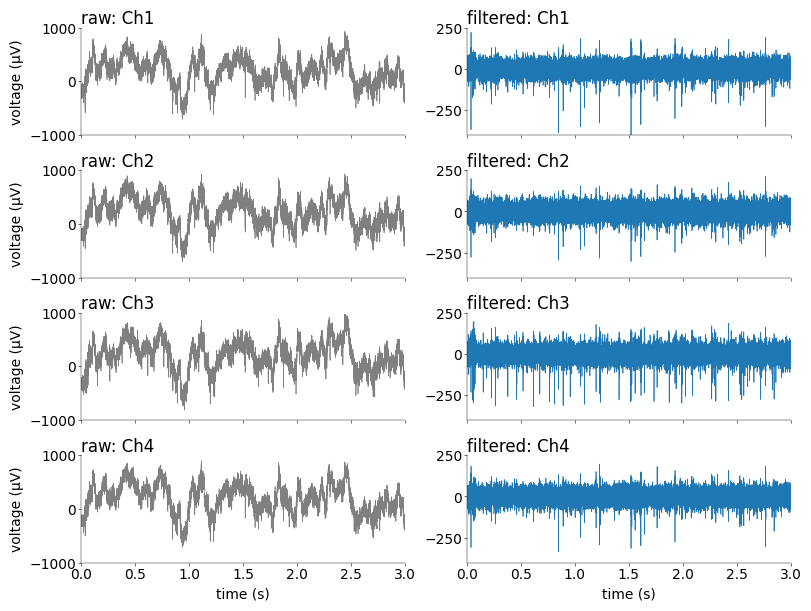

In [9]:
mosaic = [
    ["raw: Ch1", "filtered: Ch1"],
    ["raw: Ch2", "filtered: Ch2"],
    ["raw: Ch3", "filtered: Ch3"],
    ["raw: Ch4", "filtered: Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------------
# Plot raw and filtered signals for all 4 channels and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------

T = 100000
t = np.arange(0, T) * dt

for i, (raw, filtered) in enumerate(mosaic):
    ax[raw].set_xlim((0, 3))
    ax[raw].set_ylim((-1000, 1000))

    ax[filtered].set_xlim((0, 3))
    ax[filtered].set_ylim((-400, 250))

    # Extract the channel name (e.g., "Ch1") from the string "raw: Ch1"
    ch_name = raw.split(": ")[1]
    # Plot the raw signal segment
    ax[raw].plot(t, x[ch_name].iloc[:T], color="gray", lw=0.5)

    # Plot the filtered signal segment
    ax[filtered].plot(t, xf[ch_name].iloc[:T], color="tab:blue", lw=0.5)

    # Add labels and title
    ax[raw].set_ylabel("voltage (μV)")
    ax[raw].set_title(raw, loc="left")
    ax[filtered].set_title(filtered, loc="left")
    if i != 3:
        ax[raw].set_xticklabels([])
        ax[filtered].set_xticklabels([])
    else:
        ax[raw].set_xlabel("time (s)")
        ax[filtered].set_xlabel("time (s)")

### Questions
1) Explain your implementation: Which filter and parameters did you choose and why?

Filter: Butterworth: has a uniform, 'flat' gain, keeping magnitude fideltity in the spike waveform Parameters:

- Bandpass. Combination of Highpass removing LFP (eg due to sweat on electrodes or lower brainwaves) , and Lowpass, removing noise(eg due to electricity) -SOS (Second-Order Sections): Used to prevent numerical instability, which can occur in higher order filters

- zero-phase filtering, sosfiltfilt: phase distortion causes the peaks of the signal to be shifted in time. in non-real time processing, I can filter it backwards to avoid that. In real time I would chose a Bessel-Filter instead.

2) Which parameters of the function can be adjusted, which are determined by the experiment setup? What is the effect of the adjustable parameters?

Fixed by Setup: fs with 30kHz and the data itself adjustable: -low/high of the bandpass filter: if high is too low peaks get rounded off. if low is too high , there might be drifts in the signal.

- order: Increasing the order creates a steeper cutoff but is in trade-off to the Gibbson ringing effect. A 3rd-order filter (effectively 6th-order after filtfilt) provides a sharp enough cutoff without excessive ringing.

3) How does the filtered signal look compared to the original? Why is this helpful as preprocessing in our spike detection pipeline?

The raw signal has a drifting baseline (the DC offset and LFP). The filtered signal os exactly around 0V. Why it helps: It allows to define a threshhold later for spike detection. SNR: It significantly improves the Signal-to-Noise Ratio by removing the massive low-frequency power that

## Task 2: Detect action potentials

Action potentials are usually detected by finding large-amplitude deflections in the continuous signal. A good choice of threshold for detecting spikes is important. If it is too low, you will detect too many low amplitude events (noise); if it is too high, you run the risk of missing good spikes. Implement an automatic procedure to obtain a reasonable threshold and detect the times when spikes occurred in the function ```detect_spikes()```.

Plot a segment of the filtered signal for all four channels with matching y-axis and indicate the time points where you detected spikes, also **plot the threshold**.

*Grading: 4 pts*

In [10]:
def detect_spikes(
    x: np.ndarray, fs: float, N: int = 5, lockout: float = 1.0
) -> tuple[np.ndarray, np.ndarray, np.float64]:
    """Detect spikes in the signal x and compute a threshold.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal from Task 1.

    fs: float
        the sampling rate (in Hz).

    N: int
        An arbitrary number with which you multiply with the standard deviation
        to set a threshold that controls your false positive rate. Default is 5
        but you should try changing it and see how it affects the results.

    lockout: float
        a window of 'refractory period', within which there's only one spike.
        Default is 1ms but you should also try changing it.


    Returns
    -------

    s: np.array, (n_spikes, )
        Spike location / index in the signal x.

    t: np.array, (n_spikes, )
        Spike time in ms. By convention the time of the zeroth sample is 0 ms.

    thrd: float
        Threshold = -N * sigma.


    Tips
    ----

    You can use scipy functions like find_peaks for the detection.
    Note: There are four channels in signal x.

    """
    # --------------------------------------------------------------
    # compute the robust s.d. and calculate the threshold (0.5 pts)
    # --------------------------------------------------------------

    # MAD = Median of absolute values.
    #  $0.6745 is the Median of a standard normal distribution.
    # -> covers exactly 50% of the data
    # divide by 0.6745 to scale it to a full standard deviation sigma
    sigma = np.median(np.abs(x) / 0.6745)

    # Action potentials -> NEGATIVE-going dips in extracellular data
    # Multiply by N (usually 4 or 5) for threshold
    thrd = -N * sigma

    # --------------------------
    # find all spikes (1.5 pts)
    # --------------------------

    #  Channel Fusion
    #  minimum across channels
    combined_signal = np.min(x, axis=1)
    # Lockout -> Refactory period
    # Convert the lockout time (ms) into number of samples.
    d_samples = int((lockout / 1000) * fs)
    # Peak detection
    # scipy.find_peaks -> positive peaks , so using inverted input
    indices, _ = signal.find_peaks(-combined_signal, height=-thrd, distance=d_samples)

    # retrun format
    times_ms = indices * (1000.0 / fs)

    return indices, times_ms, np.float64(thrd)


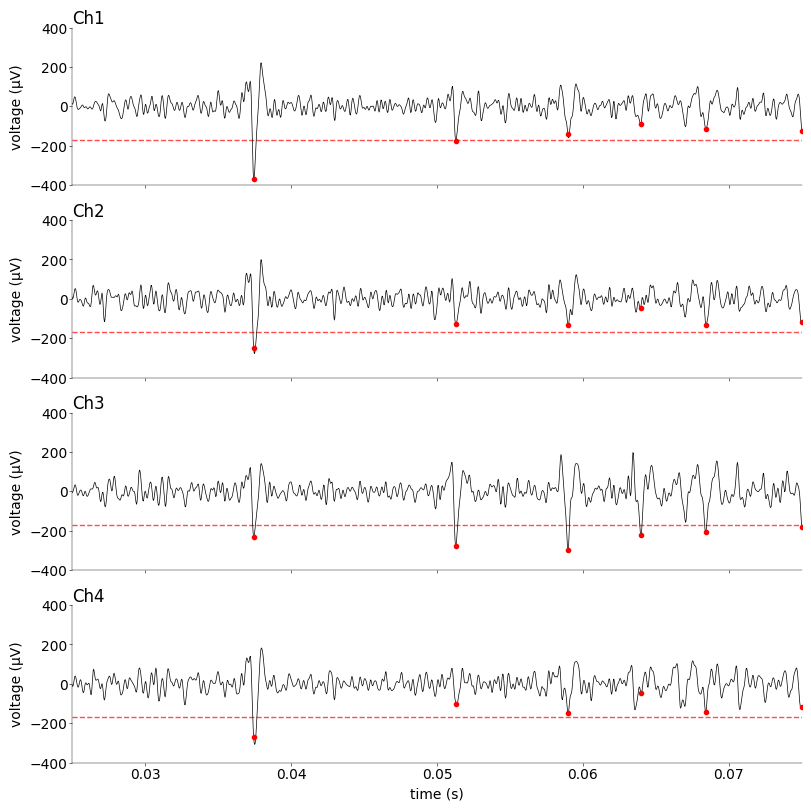

In [11]:
mosaic = [
    ["Ch1"],
    ["Ch2"],
    ["Ch3"],
    ["Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------
# plot signal, threshold and detected spikes and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------


for i, col in enumerate(cols):

    ax[col].set_ylim((-400, 400))
    ax[col].set_xlim((0.025, 0.075))
    ax[col].set_ylabel("voltage (μV)")

    ax[col].set_title(col, loc="left")

    if col != "Ch4":
        ax[col].set_xticklabels([])
    else:
        ax[col].set_xlabel("time (s)")

    # run function on the full filtered data
    s_indices, t_ms, thrd = detect_spikes(xf.values, fs, N=5, lockout=1.0)
    # Plot the threshold line
    ax[col].axhline(thrd, color="red", linestyle="--", alpha=0.7)
    # continuous filtered signal
    ax[col].plot(xf.index * dt, xf[col], color="black", lw=0.5)

    # Mark the spikes
    # Note: t_ms is in milliseconds, but the plot x-axis is in seconds!
    spike_times_sec = t_ms / 1000

    # Filter spikes  that cross the threshold
    ax[col].plot(spike_times_sec, xf[col].iloc[s_indices], "ro", markersize=3)

### Questions

1) Are the detected time points well aligned with prominent extrema in the signal? Also compare your detections across channels.

the detected points align with the local minima of the spikes Cross-Channel Comparison: Because the tetrode channels are physically close a spike from a single neuron appears on all channels at the same timestamp, but with different amplitudes

2) Take one feature of the spikes and explain how that can help us identifying the source neuron of a spike (only based on visual examination of the plot).

Relative Amplitude if a spike is very deep on Ch1 but barely visible on Ch4, the source neuron is physically closer to the Ch1 electrode tip.

## Task 3: Extract waveforms
For later spike sorting we need the waveforms of all detected spikes. Extract the waveforms segments (1 ms) on all four channels for each spike time (as a result each spike is represented by a 4x30 element matrix). Implement this procedure in the function ```extract_waveforms()```.

Plot (a) the first 100 spikes you detected and (b) the 100 largest spikes you detected.
Are there a lot of very small spikes (likely noise) among your detected spikes? If so your threshold may be too low. Can you see obvious artifacts, not looking like spikes at all?

*Grading: 3 pts*

In [12]:
def extract_waveforms(x: np.ndarray, s: np.ndarray) -> np.ndarray:
    """Extract spike waveforms at times s (given in samples)
    from the filtered signal `xf` using a fixed window around the
    times of the spikes.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal.

    s: np.array, (n_spikes, )
        Spike time in samples.


    Return
    ------

    w: np.array, (n_spikes, length_window, n_channels)
        Waveforms. (You don't have to get the exact same
        shape as we noted here. It's just the shape of w
        that can be easily retrieved via broadcasting.)


    Notes
    -----

    More on Numpy Broadcasting
    https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

    """
    # -------------------------------
    # extract spike waveforms (1 pt)
    # -------------------------------

    # Define the window size: 1 ms total
    # At 30 kHz sampling rate, 1 ms = 30 samples
    # We'll use 10 samples before and 20 samples after the spike
    before = 10  # samples before spike
    after = 20   # samples after spike
    window_size = before + after  # 30 samples total
    
    # Initialize array to hold waveforms
    n_spikes = len(s)
    n_channels = x.shape[1]
    w = np.zeros((n_spikes, window_size, n_channels))
    
    # Extract waveforms for each spike
    for i, spike_idx in enumerate(s):
        spike_idx = int(spike_idx)
        # Make sure we don't go out of bounds
        if spike_idx - before >= 0 and spike_idx + after <= len(x):
            w[i, :, :] = x[spike_idx - before:spike_idx + after, :]
    
    return w



Plot first 100 spike waveforms

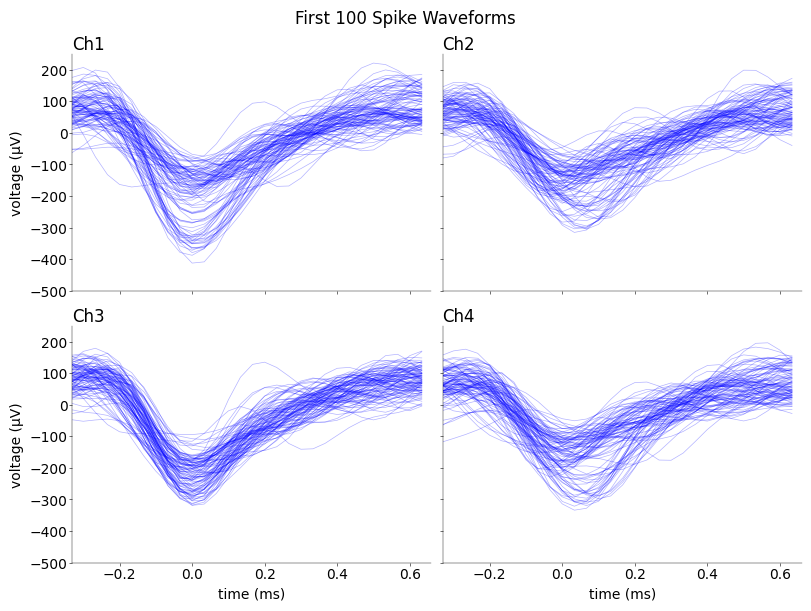

In [13]:
# ---------------------------------------------------------------------
# plot first and largest 100 spikes and answer the questions (1+1 pts)
# ---------------------------------------------------------------------

# first 100 spikes

# Get waveforms
w = extract_waveforms(xf.values, s_indices)

# Create time axis for waveforms (1 ms window at 30 kHz)
dt = 1/fs  # time step
before = 10
after = 20
time_wf = np.arange(-before, after) * dt * 1000  # convert to ms

cols = ["Ch1", "Ch2", "Ch3", "Ch4"]

# first 100 spikes
mosaic = [
    ["Ch1", "Ch2"],
    ["Ch3", "Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

for i, col in enumerate(cols):
    # Plot first 100 waveforms for this channel
    for j in range(100):
        ax[col].plot(time_wf, w[j, :, i], alpha=0.3, color='blue', linewidth=0.5)
    
    # labeling etc
    ax[col].set_ylim((-500, 250))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

plt.suptitle("First 100 Spike Waveforms")
plt.show()

Plot largest 100 spike waveforms

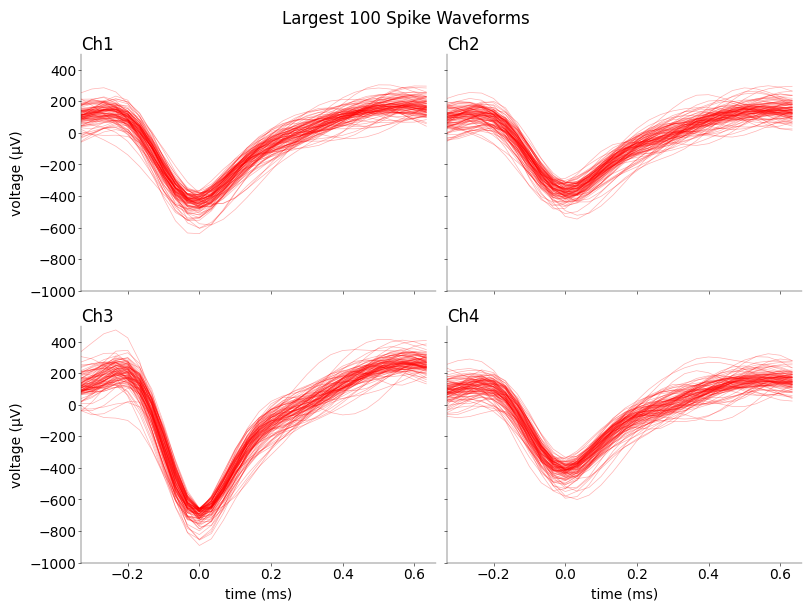

In [14]:
# largest 100 spikes

# Find the 100 largest spikes (by maximum amplitude across all channels)
spike_amplitudes = np.max(np.abs(w), axis=(1, 2))  # max absolute value per spike
largest_idx = np.argsort(spike_amplitudes)[-100:]  # indices of 100 largest

fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

for i, col in enumerate(cols):
    # Plot largest 100 waveforms for this channel
    for j in largest_idx:
        ax[col].plot(time_wf, w[j, :, i], alpha=0.3, color='red', linewidth=0.5)
    
    # labeling etc
    ax[col].set_ylim((-1000, 500))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

plt.suptitle("Largest 100 Spike Waveforms")
plt.show()

### Questions

1) Describe the shape of the spikes.

The spikes show the characteristic bi-phasic waveform, where a negative deflection is followed by a positive deflection. There is also a negative deflection that reaches the minimum around 0 ms.

2) Do the waveforms tend to be similar? If spikes have a similar waveform, what could that mean - and what does it mean if the waveforms look different?

Yes, the waveforms look highly similar to each other. This suggests that the spikes might have originated from the same neuron.

If the waveforms looked different, it would suggest that multiple neurons were being detected.

## Task 4: Extract features using PCA
Compute the first three PCA features on each channel separately in ```extract_features()```. You can use a available PCA implementation or implement it yourself. After that, each spike is represented by a 12 element vector. Compute the fraction of variance captured by these three PCs. Also return the obtained parameters of the PCA

For one channel, plot the mean and the first three principal axes as calculated by the PCA in the feature space. Interprete them in light of the plots in the previous tasks.

For all pairwise combinations of channels, plot the resulting features of the 1st PCs as scatter plots against each other. Do you see clusters visually?

*Grading: 6 pts*

## PCA
### Questions (1 pt)
1) If we input the data from each channel separately to a PCA, what are the feature dimension of the input?

The input feature dimension is the length of the waveform window, which is 30 samples (representing 1 ms at 30 kHz sampling rate). Each spike waveform on a single channel is a 30-dimensional vector, where each dimension corresponds to the voltage value at one time point.


2) Therefore, what do the Principal Axes the PCA computes represent?

The principal axes (principal components) represent the main directions of variance in the 30-dimensional waveform space. Each principal component is a 30-element vector (same length as the waveform) that describes a particular pattern or "template waveform." The first PC captures the most common variation pattern across all spike waveforms, the second PC captures the second most common variation (orthogonal to the first), and so on.

3) Does it make sense to apply preprocessing steps, such as normalization? Have a look at the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). What is applied by default?
Yes, preprocessing makes sense. According to the scikit-learn documentation, PCA centers the data by default (subtracting the mean from each feature). This centering is important because PCA is based on finding directions of maximum variance, and centering ensures we're measuring variance around the true center of the data rather than around the origin.
However, sklearn's PCA does NOT standardize (scale to unit variance) by default. For spike waveforms, this default behavior is actually appropriate because we want to preserve the relative amplitude information across different time points. The temporal dynamics and amplitude of spikes are meaningful features we don't want to lose through standardization.


In [15]:
def extract_features(w: np.ndarray) -> np.ndarray:
    """Extract features for spike sorting from the waveforms w.

    Do PCA on the waveforms of each channel separately,
    then concatenate the first three principal components
    of each channels into one numpy array (`b`).


    Parameter
    ---------

    w: np.ndarray, (n_spikes, length_window, n_channels)
        Waveforms from Task 3.


    Return
    ------

    b: np.ndarray, (n_spikes, n_feature)
        the transformed data
    means: np.ndarray, (n_channels, length_window)
        means per channel
    principal_components: np.ndarray, (n_channels, 3, length_window)
        the 'principal axes' obtained by the pca


    Notes
    -----

    You can use PCA from sklearn.

    More on PCA
    https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html

    """

    from sklearn.decomposition import PCA

    # ----------------------------------------------
    # obtain first 3 principle components (1.5 pts)
    # ----------------------------------------------

    n_spikes, length_window, n_channels = w.shape
    n_components = 3

    b = np.zeros((n_spikes, n_channels * n_components))
    means = np.zeros((n_channels, length_window))
    principal_components = np.zeros((n_channels, n_components, length_window))

    for ch in range(n_channels):
        # extracting waveforms for the channel
        waveform = w[:, :, ch]

        # applying PCA
        pca = PCA(n_components=n_components)
        features_ch = pca.fit_transform(waveform)

        # storing features in b
        b[:, ch*n_components:(ch+1)*n_components] = features_ch
        means[ch, :] = pca.mean_

        # Store the principal components 
        principal_components[ch, :, :] = pca.components_


    # -----------------------------------------------------------------------------------------------------
    # Print the fraction of variance explained by the three components combined for each channel (0.5 pts)
    # -----------------------------------------------------------------------------------------------------

        variance_explained = np.sum(pca.explained_variance_ratio_)
        print(f"Channel {ch+1}: Variance explained by first 3 PCs = {variance_explained:.4f} ({variance_explained*100:.2f}%)")
        
    return b, means, principal_components

b, means, principal_components = extract_features(w)

Channel 1: Variance explained by first 3 PCs = 0.8261 (82.61%)
Channel 2: Variance explained by first 3 PCs = 0.7668 (76.68%)
Channel 3: Variance explained by first 3 PCs = 0.8067 (80.67%)
Channel 4: Variance explained by first 3 PCs = 0.7901 (79.01%)


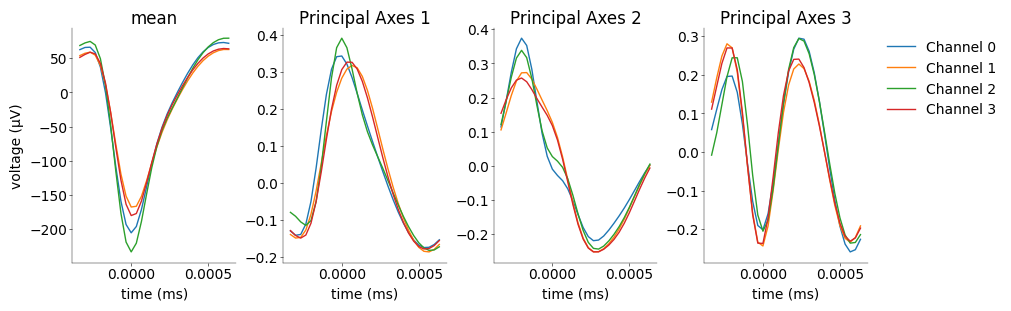

In [16]:
# ------------------------------------------------------------------------------------------------------------------
# Plot the mean of each channel and the three principal axes obtained by the PCA and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------------------------------------

mosaic = [
    ["mean", "Principal Axes 1", "Principal Axes 2", "Principal Axes 3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(10, 3), layout="constrained", dpi=100
)

# time axis
left = 10
right = 20
time_wf = np.arange(-before, after) * dt  # in s

for channel in range(4):

    # Plot mean
    ax["mean"].plot(time_wf, means[channel, :], label=f'Channel {channel+1}')

    for i in range(3):
        mo = f"Principal Axes {i+1}"
        ax[mo].plot(time_wf, principal_components[channel, i, :], label=f'Channel {channel+1}')


        
    for i, mo in enumerate(np.ravel(mosaic)):
        ax[mo].set_xlabel("time (ms)")
        ax[mo].set_title(mo)

ax[mosaic[0][0]].set_ylabel("voltage (μV)")
ax[mosaic[0][-1]].legend(
    ["Channel " + str(i) for i in range(4)],
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)
plt.show()

### Questions

1) Compare the plot to the plots of the other tasks. What do you observe?
The mean waveform closely resembles the individual spike waveforms seen in Task 3, showing the same characteristic biphasic shape with a negative deflection followed by a positive deflection. This confirms that the spikes are highly consistent


2) What does the mean look like? Does this match your expectations?

 We observed that the individual waveforms are highly similar and stereotyped. The mean represents the "average spike" from this neuron. The fact that it looks like a clean spike confirms that we're detecting real, consistent action potentials from a well-isolated single unit.

3) Explain what it means if a spike has a high value in the first dimension. What is the effect of the other dimensions?
A high (positive) value in the first principal component dimension typically means the spike has a larger amplitude than average - the negative and positive deflections are more pronounced. A negative value would indicate a smaller-than-average spike. PC1 captures the main variation in overall spike magnitude.

The second and third dimensions (PC2 and PC3) capture more subtle shape variations that are orthogonal to (independent of) the amplitude. Together, these three PCs provide a compressed representation that captures most of the variance in the spike waveforms while reducing the dimensionality from 30 (time samples) to just 3 features per channel, making clustering and spike sorting much more computationally efficient.

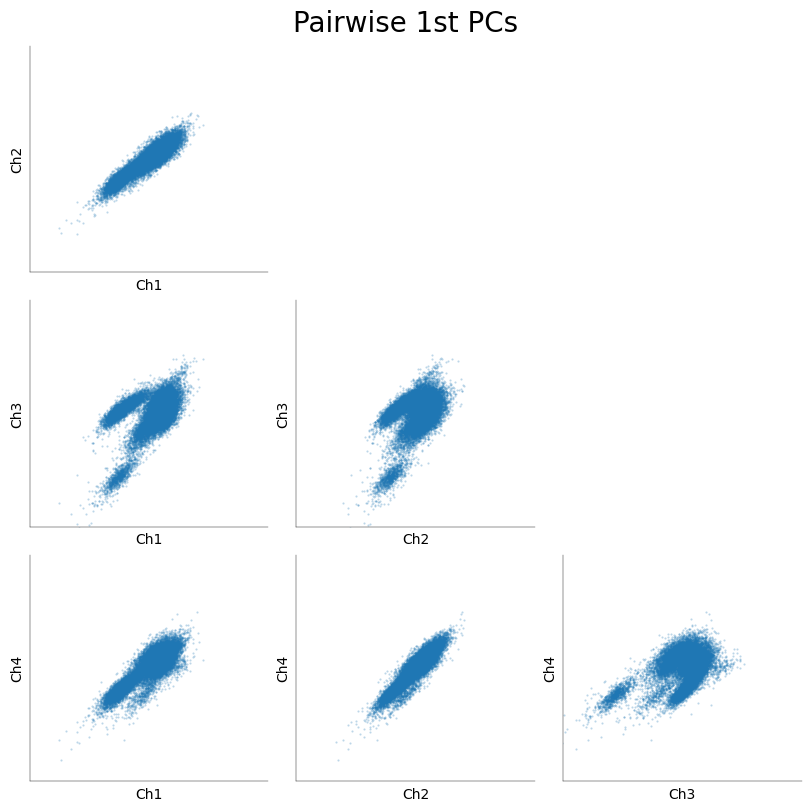

In [17]:
# ----------------------------------------------------------------------------------------------------------
# Create a scatterplot of the projections of the spikes for all pairwise combinations of the 1st PCs (1 pt)
# ----------------------------------------------------------------------------------------------------------

mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue
    y, x = mo.split(" vs ")
    
    # Plot scatter of 1st PC from two channels
    ax[mo].scatter(b[:, i[x]], b[:, i[y]], alpha=0.3, s=1)
    
    ax[mo].set_xlabel(x)
    ax[mo].set_ylabel(y)
    ax[mo].set_xlim((-1500, 1500))
    ax[mo].set_ylim((-1500, 1500))
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

fig.suptitle("Pairwise 1st PCs", fontsize=20)
plt.show()

In [18]:
# save data for the next Coding Lab

np.save("../data/nds_cl_1_features", b)
np.save("../data/nds_cl_1_spiketimes_s", s_indices)
np.save("../data/nds_cl_1_spiketimes_t", t)
np.save("../data/nds_cl_1_waveforms", w)